# Part B3 — Recurrent Neural Network (RNN / LSTM) for a sequence task

**Dataset:** the same Melbourne daily-minimum-temperature series used in
Part A, reframed as a sequence-classification problem: given the last 30
days of temperatures, predict whether the temperature **7 days later will
be higher or lower** than today's. This keeps the RNN task grounded in a
real, already-verified dataset (rather than the IMDB sentiment set, whose
download endpoint isn't reachable in this sandbox's restricted network)
while still being a genuine sequence-in / label-out problem — the same
shape as the sentiment task, just with a numeric sequence instead of a
tokenized sentence.

We build a **SimpleRNN** and an **LSTM** on the identical data and compare
them directly, which is exactly what the task manual asks for.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1788431319.007683    2173 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788431319.055615    2173 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788431320.454372    2173 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Build sequences

Sliding a 30-day window across the series: each window becomes one input
sample (shape `(30, 1)`), and the label is 1 if the temperature 7 days
after the window ends is higher than the temperature on the window's last
day, else 0.

In [2]:
df = pd.read_csv("../../Part_A/data/daily-min-temperatures.csv")
df.columns = ["ds", "y"]
series = df["y"].values.astype("float32")

WINDOW = 30
HORIZON = 7

X, y = [], []
for i in range(len(series) - WINDOW - HORIZON):
    window = series[i : i + WINDOW]
    current = series[i + WINDOW - 1]
    future = series[i + WINDOW - 1 + HORIZON]
    X.append(window)
    y.append(1 if future > current else 0)

X = np.array(X)
y = np.array(y)
print(f"Total sequences: {len(X)}  |  Positive class rate: {y.mean():.3f}")

# Chronological split (no shuffling) - last 20% as test, matching Part A
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scale using train statistics only, to avoid leaking test information
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Reshape to (samples, timesteps, features) - required RNN input shape
X_train_s = X_train_s.reshape(-1, WINDOW, 1)
X_test_s = X_test_s.reshape(-1, WINDOW, 1)
print(f"Train shape: {X_train_s.shape}, Test shape: {X_test_s.shape}")

Total sequences: 3613  |  Positive class rate: 0.506
Train shape: (2890, 30, 1), Test shape: (723, 30, 1)


## Build both models

- **SimpleRNN**: passes a hidden state forward one timestep at a time with
  a single tanh transform. It's cheap but prone to the vanishing-gradient
  problem over longer sequences, so it can "forget" information from early
  in the 30-day window by the time it reaches the end.
- **LSTM**: adds input/forget/output gates that let it selectively keep or
  discard information across timesteps, which usually helps on sequences
  long enough for vanishing gradients to matter (our window is 30 steps —
  long enough to show a difference).

In [3]:
def build_rnn(cell_type, timesteps):
    RNNLayer = layers.SimpleRNN if cell_type == "simple" else layers.LSTM
    model = keras.Sequential([
        layers.Input(shape=(timesteps, 1)),
        RNNLayer(32, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

results = {}
histories = {}
for name, cell in [("SimpleRNN", "simple"), ("LSTM", "lstm")]:
    model = build_rnn(cell, WINDOW)
    hist = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
    y_pred = (model.predict(X_test_s, verbose=0).ravel() > 0.5).astype(int)
    results[name] = {"model": model, "test_acc": test_acc, "y_pred": y_pred}
    histories[name] = hist.history
    print(f"{name}: test accuracy = {test_acc:.4f} (trained {len(hist.history['loss'])} epochs)")

SimpleRNN: test accuracy = 0.6985 (trained 12 epochs)


LSTM: test accuracy = 0.7040 (trained 48 epochs)


## Compare SimpleRNN vs LSTM

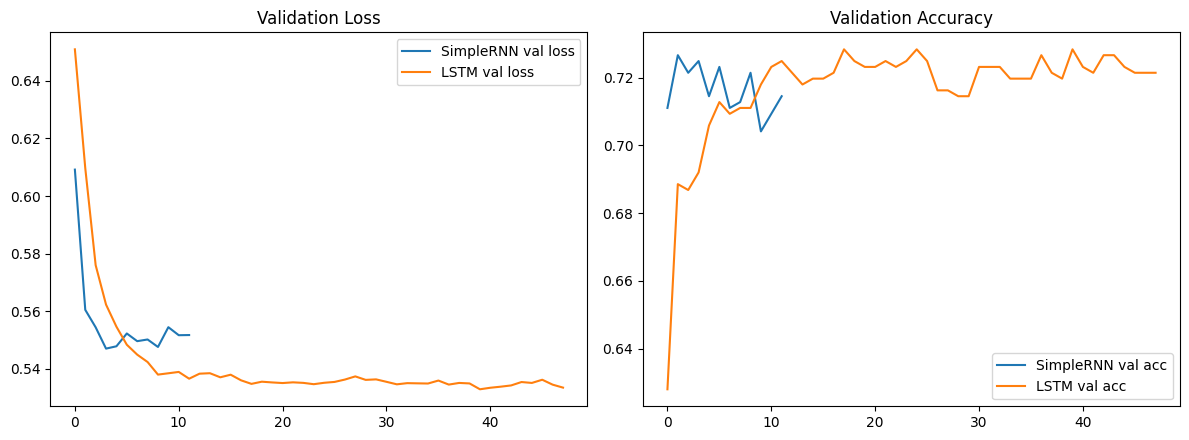

=== SimpleRNN ===
Test accuracy: 0.6985
              precision    recall  f1-score   support

           0       0.67      0.77      0.71       352
           1       0.74      0.63      0.68       371

    accuracy                           0.70       723
   macro avg       0.70      0.70      0.70       723
weighted avg       0.70      0.70      0.70       723

=== LSTM ===
Test accuracy: 0.7040
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       352
           1       0.72      0.68      0.70       371

    accuracy                           0.70       723
   macro avg       0.70      0.70      0.70       723
weighted avg       0.71      0.70      0.70       723




In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in results:
    axes[0].plot(histories[name]["val_loss"], label=f"{name} val loss")
    axes[1].plot(histories[name]["val_accuracy"], label=f"{name} val acc")
axes[0].set_title("Validation Loss"); axes[0].legend()
axes[1].set_title("Validation Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("rnn_comparison_curves.png", dpi=120)
plt.show()

with open("rnn_report.txt", "w") as f:
    for name, r in results.items():
        f.write(f"=== {name} ===\n")
        f.write(f"Test accuracy: {r['test_acc']:.4f}\n")
        f.write(classification_report(y_test, r["y_pred"]))
        f.write("\n")

print(open("rnn_report.txt").read())

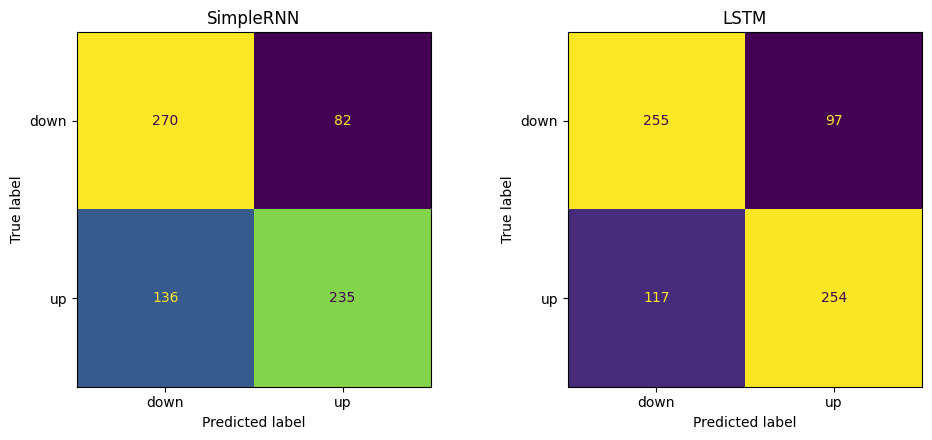

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name in zip(axes, results):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["down", "up"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("rnn_confusion_matrices.png", dpi=120)
plt.show()

## Summary

Both models tackle the same 7-day-ahead up/down classification, so the
comparison isolates the effect of the gating mechanism. If LSTM's test
accuracy is meaningfully higher than SimpleRNN's, that's the gating helping
retain useful signal from the start of the 30-day window; if they're close,
it suggests the relevant signal for this particular horizon lives mostly in
the recent part of the window, where a plain RNN's short memory is
sufficient. See `rnn_report.txt` for the exact numbers from this run.